# SegFormer for Semantic Segmentation

Implementation of SegFormer (Xie et al., NeurIPS 2021) from scratch.

**Architecture (following the lecture slides):**
- **Encoder:** Hierarchical Mix Transformer (MiT) with 4 stages, efficient self-attention (SRA), Mix-FFN, and overlapping patch embeddings.
- **Decoder:** Lightweight All-MLP head that fuses multi-scale features.

**Key differences from ViT:**
1. Hierarchical multi-scale structure (not single-scale).
2. Spatial-Reduction Attention (SRA) for efficiency.
3. Mix-FFN with depthwise convolution (replaces positional encoding).
4. Overlapping patch embeddings (preserves local continuity).

**Dependencies:** `torch`, `torchvision`, `numpy`, `matplotlib`, `scikit-learn`, `tqdm`, `Pillow`

## 1. Setup

In [1]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2. SegFormer Encoder Components

### 2.1 Overlapping Patch Embedding

Unlike ViT's non-overlapping patches ($16 \times 16$, stride 16), SegFormer uses overlapping patches to preserve local continuity. Stage 1 uses $7 \times 7$ kernel with stride 4; subsequent stages use $3 \times 3$ with stride 2.

In [2]:
class OverlapPatchEmbed(nn.Module):
    """Overlapped Patch Embedding (stride < kernel_size)."""
    def __init__(self, patch_size=7, stride=4, in_channels=3, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=stride,
            padding=patch_size // 2
        )
        self.norm = nn.LayerNorm(embed_dim)
    
    def forward(self, x):
        x = self.proj(x)                          # (B, C, H', W')
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)          # (B, H'*W', C)
        x = self.norm(x)
        return x, H, W

### 2.2 Efficient Self-Attention with Spatial Reduction (SRA)

Standard self-attention has $O(n^2)$ complexity. SRA reduces the spatial dimensions of $\mathbf{K}$ and $\mathbf{V}$ by factor $R$, reducing complexity to $O(n^2/R^2)$.

Higher-resolution stages use larger reduction ratios ($R=8$ for stage 1, $R=1$ for stage 4).

In [3]:
class EfficientSelfAttention(nn.Module):
    """Self-Attention with Spatial Reduction for K and V."""
    def __init__(self, dim, num_heads=8, sr_ratio=1):
        super().__init__()
        assert dim % num_heads == 0
        
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.sr_ratio = sr_ratio
        
        self.q = nn.Linear(dim, dim)
        self.kv = nn.Linear(dim, dim * 2)
        
        # Spatial reduction via strided convolution
        if sr_ratio > 1:
            self.sr = nn.Conv2d(dim, dim, kernel_size=sr_ratio, stride=sr_ratio)
            self.norm = nn.LayerNorm(dim)
        
        self.proj = nn.Linear(dim, dim)
    
    def forward(self, x, H, W):
        B, N, C = x.shape
        
        # Query: full resolution
        q = self.q(x).reshape(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        
        # Key, Value: spatially reduced
        if self.sr_ratio > 1:
            x_ = x.permute(0, 2, 1).reshape(B, C, H, W)
            x_ = self.sr(x_).reshape(B, C, -1).permute(0, 2, 1)
            x_ = self.norm(x_)
            kv = self.kv(x_).reshape(B, -1, 2, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        else:
            kv = self.kv(x).reshape(B, N, 2, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        
        k, v = kv[0], kv[1]
        
        # Attention
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(x)

### 2.3 Mix-FFN

Replaces traditional positional encoding with a $3 \times 3$ depthwise convolution inside the FFN:

$$\text{Mix-FFN}(\mathbf{z}) = \mathbf{W}_2 \cdot \text{GELU}(\text{DWConv}_{3 \times 3}(\mathbf{W}_1 \mathbf{z} + \mathbf{b}_1)) + \mathbf{b}_2$$

This provides positional information implicitly and works across different input resolutions.

In [4]:
class MixFFN(nn.Module):
    """FFN with depthwise conv for implicit positional encoding."""
    def __init__(self, in_features, hidden_features=None, out_features=None):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.dwconv = nn.Conv2d(
            hidden_features, hidden_features,
            kernel_size=3, stride=1, padding=1,
            groups=hidden_features   # depthwise
        )
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
    
    def forward(self, x, H, W):
        B, N, C = x.shape
        x = self.fc1(x)
        hidden_C = x.shape[-1]
        # Apply depthwise conv in spatial domain
        x = x.permute(0, 2, 1).reshape(B, hidden_C, H, W)
        x = self.dwconv(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.act(x)
        x = self.fc2(x)
        return x

### 2.4 DropPath and Transformer Block

In [5]:
class DropPath(nn.Module):
    """Stochastic Depth: drop entire residual paths during training."""
    def __init__(self, drop_prob=0.):
        super().__init__()
        self.drop_prob = drop_prob
    
    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        return x.div(keep_prob) * random_tensor


class TransformerBlock(nn.Module):
    """SegFormer Transformer Block: SRA-Attention + Mix-FFN with residuals."""
    def __init__(self, dim, num_heads, mlp_ratio=4, sr_ratio=1, drop_path=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = EfficientSelfAttention(dim, num_heads=num_heads, sr_ratio=sr_ratio)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MixFFN(in_features=dim, hidden_features=int(dim * mlp_ratio))
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
    
    def forward(self, x, H, W):
        x = x + self.drop_path(self.attn(self.norm1(x), H, W))
        x = x + self.drop_path(self.mlp(self.norm2(x), H, W))
        return x

## 3. Complete SegFormer Model

### 3.1 Hierarchical Encoder (4 stages)

Each stage: Overlapping Patch Embed + N Transformer Blocks. Progressive downsampling creates a multi-scale feature pyramid.

In [6]:
class MixTransformerStage(nn.Module):
    """One stage: patch embedding + transformer blocks."""
    def __init__(self, patch_size, stride, in_channels, embed_dim,
                 num_heads, depth, sr_ratio, mlp_ratio=4, drop_path_rate=0.):
        super().__init__()
        self.patch_embed = OverlapPatchEmbed(patch_size, stride, in_channels, embed_dim)
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, sr_ratio, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
    
    def forward(self, x):
        x, H, W = self.patch_embed(x)
        for block in self.blocks:
            x = block(x, H, W)
        x = self.norm(x)
        B, N, C = x.shape
        x = x.permute(0, 2, 1).reshape(B, C, H, W)
        return x


class MixTransformerEncoder(nn.Module):
    """4-stage hierarchical encoder."""
    def __init__(self, in_channels=3, embed_dims=[32, 64, 160, 256],
                 num_heads=[1, 2, 5, 8], depths=[2, 2, 2, 2],
                 sr_ratios=[8, 4, 2, 1], mlp_ratios=[4, 4, 4, 4],
                 drop_path_rate=0.1):
        super().__init__()
        self.stages = nn.ModuleList()
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        cur = 0
        
        for i in range(4):
            if i == 0:
                ps, s, in_ch = 7, 4, in_channels
            else:
                ps, s, in_ch = 3, 2, embed_dims[i-1]
            
            self.stages.append(MixTransformerStage(
                ps, s, in_ch, embed_dims[i], num_heads[i],
                depths[i], sr_ratios[i], mlp_ratios[i],
                sum(dpr[cur:cur+depths[i]]) / depths[i]
            ))
            cur += depths[i]
    
    def forward(self, x):
        outputs = []
        for stage in self.stages:
            x = stage(x)
            outputs.append(x)
        return outputs

### 3.2 All-MLP Decoder

For each stage $i$, the decoder: (1) projects features to a unified dimension with a $1 \times 1$ conv, (2) upsamples to $H/4 \times W/4$ resolution, (3) concatenates all, and (4) fuses with an MLP.

In [7]:
class SegFormerHead(nn.Module):
    """Lightweight All-MLP decoder."""
    def __init__(self, in_channels=[32, 64, 160, 256], embedding_dim=256, num_classes=1):
        super().__init__()
        self.linear_c = nn.ModuleList([
            nn.Conv2d(in_ch, embedding_dim, kernel_size=1) for in_ch in in_channels
        ])
        self.linear_fuse = nn.Sequential(
            nn.Conv2d(embedding_dim * 4, embedding_dim, kernel_size=1),
            nn.BatchNorm2d(embedding_dim),
            nn.ReLU(inplace=True)
        )
        self.linear_pred = nn.Conv2d(embedding_dim, num_classes, kernel_size=1)
    
    def forward(self, features):
        B, _, H, W = features[0].shape
        target_size = (H, W)
        
        upsampled = []
        for i, feat in enumerate(features):
            mlp_feat = self.linear_c[i](feat)
            upsampled.append(F.interpolate(mlp_feat, size=target_size, mode='bilinear', align_corners=False))
        
        fused = self.linear_fuse(torch.cat(upsampled, dim=1))
        return self.linear_pred(fused)

### 3.3 Complete SegFormer

In [8]:
class SegFormer(nn.Module):
    """Complete SegFormer: Encoder (MiT) + Decoder (All-MLP Head)."""
    def __init__(self, num_classes=1, embed_dims=[32, 64, 160, 256],
                 num_heads=[1, 2, 5, 8], depths=[2, 2, 2, 2],
                 sr_ratios=[8, 4, 2, 1], mlp_ratios=[4, 4, 4, 4],
                 drop_path_rate=0.1, decoder_embed_dim=256):
        super().__init__()
        self.encoder = MixTransformerEncoder(
            3, embed_dims, num_heads, depths, sr_ratios, mlp_ratios, drop_path_rate
        )
        self.decoder = SegFormerHead(embed_dims, decoder_embed_dim, num_classes)
    
    def forward(self, x):
        input_size = x.shape[-2:]
        features = self.encoder(x)
        out = self.decoder(features)
        return F.interpolate(out, size=input_size, mode='bilinear', align_corners=False)

# Create model (MiT-B0 configuration)
model = SegFormer(
    num_classes=1,
    embed_dims=[32, 64, 160, 256],
    num_heads=[1, 2, 5, 8],
    depths=[2, 2, 2, 2],
    sr_ratios=[8, 4, 2, 1],
    decoder_embed_dim=256
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print()
print(model)

Total parameters: 3,714,657

SegFormer(
  (encoder): MixTransformerEncoder(
    (stages): ModuleList(
      (0): MixTransformerStage(
        (patch_embed): OverlapPatchEmbed(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (blocks): ModuleList(
          (0): TransformerBlock(
            (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
            (attn): EfficientSelfAttention(
              (q): Linear(in_features=32, out_features=32, bias=True)
              (kv): Linear(in_features=32, out_features=64, bias=True)
              (sr): Conv2d(32, 32, kernel_size=(8, 8), stride=(8, 8))
              (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
              (proj): Linear(in_features=32, out_features=32, bias=True)
            )
            (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
            (mlp): MixFFN(
     

## 4. Dataset

We use a binary segmentation dataset with images in `./images/geostar/orig/` and masks in `./images/geostar/label/`. Masks are binarized (foreground/background).

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class SegmentationDataset(Dataset):
    def __init__(self, image_files, img_dir, mask_dir, img_size=(512, 512)):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.image_files = image_files
        self.img_transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ])
        self.mask_transform = transforms.Resize(img_size, interpolation=transforms.InterpolationMode.NEAREST)
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_file = self.image_files[idx]
        img = Image.open(self.img_dir / img_file).convert('RGB')
        mask = Image.open(self.mask_dir / img_file).convert('L')
        
        img = self.img_transform(img)
        mask = self.mask_transform(mask)
        mask = (np.array(mask, dtype=np.uint8) > 127).astype(np.uint8)
        mask = torch.from_numpy(mask).long()
        return img, mask, img_file

In [10]:
# Load dataset
IMG_DIR  = '../images/geostar/orig'
MASK_DIR = '../images/geostar/label'
IMG_SIZE = (512, 512)

image_files = sorted([f for f in os.listdir(IMG_DIR) 
                      if f.endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))])

# Verify masks exist
valid_files = [f for f in image_files if (Path(MASK_DIR) / f).exists()]
print(f"Found {len(valid_files)} valid image-mask pairs")

# Split
train_files, test_files = train_test_split(valid_files, test_size=0.2, random_state=42)
print(f"Training: {len(train_files)}, Test: {len(test_files)}")

train_dataset = SegmentationDataset(train_files, IMG_DIR, MASK_DIR, IMG_SIZE)
test_dataset  = SegmentationDataset(test_files, IMG_DIR, MASK_DIR, IMG_SIZE)

BATCH_SIZE = 4
trainload = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
testload  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Found 151 valid image-mask pairs
Training: 120, Test: 31


## 5. Training

In [11]:
def dice_score(pred, target, num_classes=2, smooth=1e-6):
    scores = []
    for cls in range(num_classes):
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        scores.append(((2.0 * intersection + smooth) / (union + smooth)).item())
    return scores, np.mean(scores)

def train_epoch(model, dataloader, optimizer, device, pos_weight=None):
    model.train()
    total_loss = 0
    for imgs, masks, _ in dataloader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = F.binary_cross_entropy_with_logits(
            logits.squeeze(1), masks.float(),
            pos_weight=pos_weight
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

@torch.no_grad()
def evaluate(model, dataloader, device, num_classes=2):
    model.eval()
    all_scores = []
    for imgs, masks, _ in dataloader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        preds = (torch.sigmoid(logits.squeeze(1)) > 0.5).long()
        scores, _ = dice_score(preds, masks, num_classes)
        all_scores.append(scores)
    all_scores = np.array(all_scores)
    return all_scores.mean(axis=0), all_scores.mean()

In [12]:
# Calculate class imbalance for pos_weight
print("Analyzing class imbalance...")
total_px, fg_px = 0, 0
for _, mask, _ in train_dataset:
    total_px += mask.numel()
    fg_px += mask.sum().item()
bg_px = total_px - fg_px
imbalance = bg_px / max(fg_px, 1)
print(f"Background: {100*bg_px/total_px:.1f}%, Foreground: {100*fg_px/total_px:.1f}%")
print(f"Imbalance ratio: {imbalance:.1f}:1")
pos_weight = torch.tensor([imbalance]).to(device)

Analyzing class imbalance...
Background: 81.4%, Foreground: 18.6%
Imbalance ratio: 4.4:1


In [13]:
# Training loop
NUM_EPOCHS = 200
WARMUP_EPOCHS = 10
EARLY_STOPPING = 25
LR = 1e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / (NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

train_losses, test_dices = [], []
best_dice, patience = 0.0, 0

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, trainload, optimizer, device, pos_weight)
    dice_per_class, mean_dice = evaluate(model, testload, device)
    scheduler.step()
    
    train_losses.append(train_loss)
    test_dices.append(mean_dice)
    
    fg_dice = dice_per_class[1]
    if fg_dice > best_dice:
        best_dice = fg_dice
        torch.save(model.state_dict(), 'best_segformer.pth')
        patience = 0
    else:
        patience += 1
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} -- Loss: {train_loss:.4f}, "
              f"DICE: {mean_dice:.4f} (BG: {dice_per_class[0]:.4f}, FG: {dice_per_class[1]:.4f})")
    
    if patience >= EARLY_STOPPING:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest foreground DICE: {best_dice:.4f}")

Epoch  20/200 -- Loss: 0.7039, DICE: 0.6661 (BG: 0.8257, FG: 0.5065)
Epoch  40/200 -- Loss: 0.2801, DICE: 0.6734 (BG: 0.8774, FG: 0.4694)
Early stopping at epoch 45

Best foreground DICE: 0.5065


## 6. Results

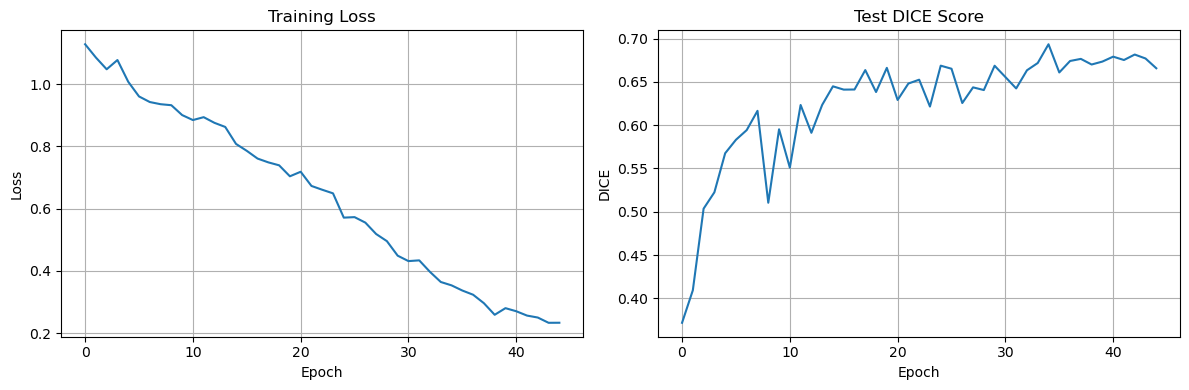

In [14]:
# Plot curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Training Loss'); ax1.grid(True)
ax2.plot(test_dices); ax2.set_xlabel('Epoch'); ax2.set_ylabel('DICE'); ax2.set_title('Test DICE Score'); ax2.grid(True)
plt.tight_layout()
plt.show()

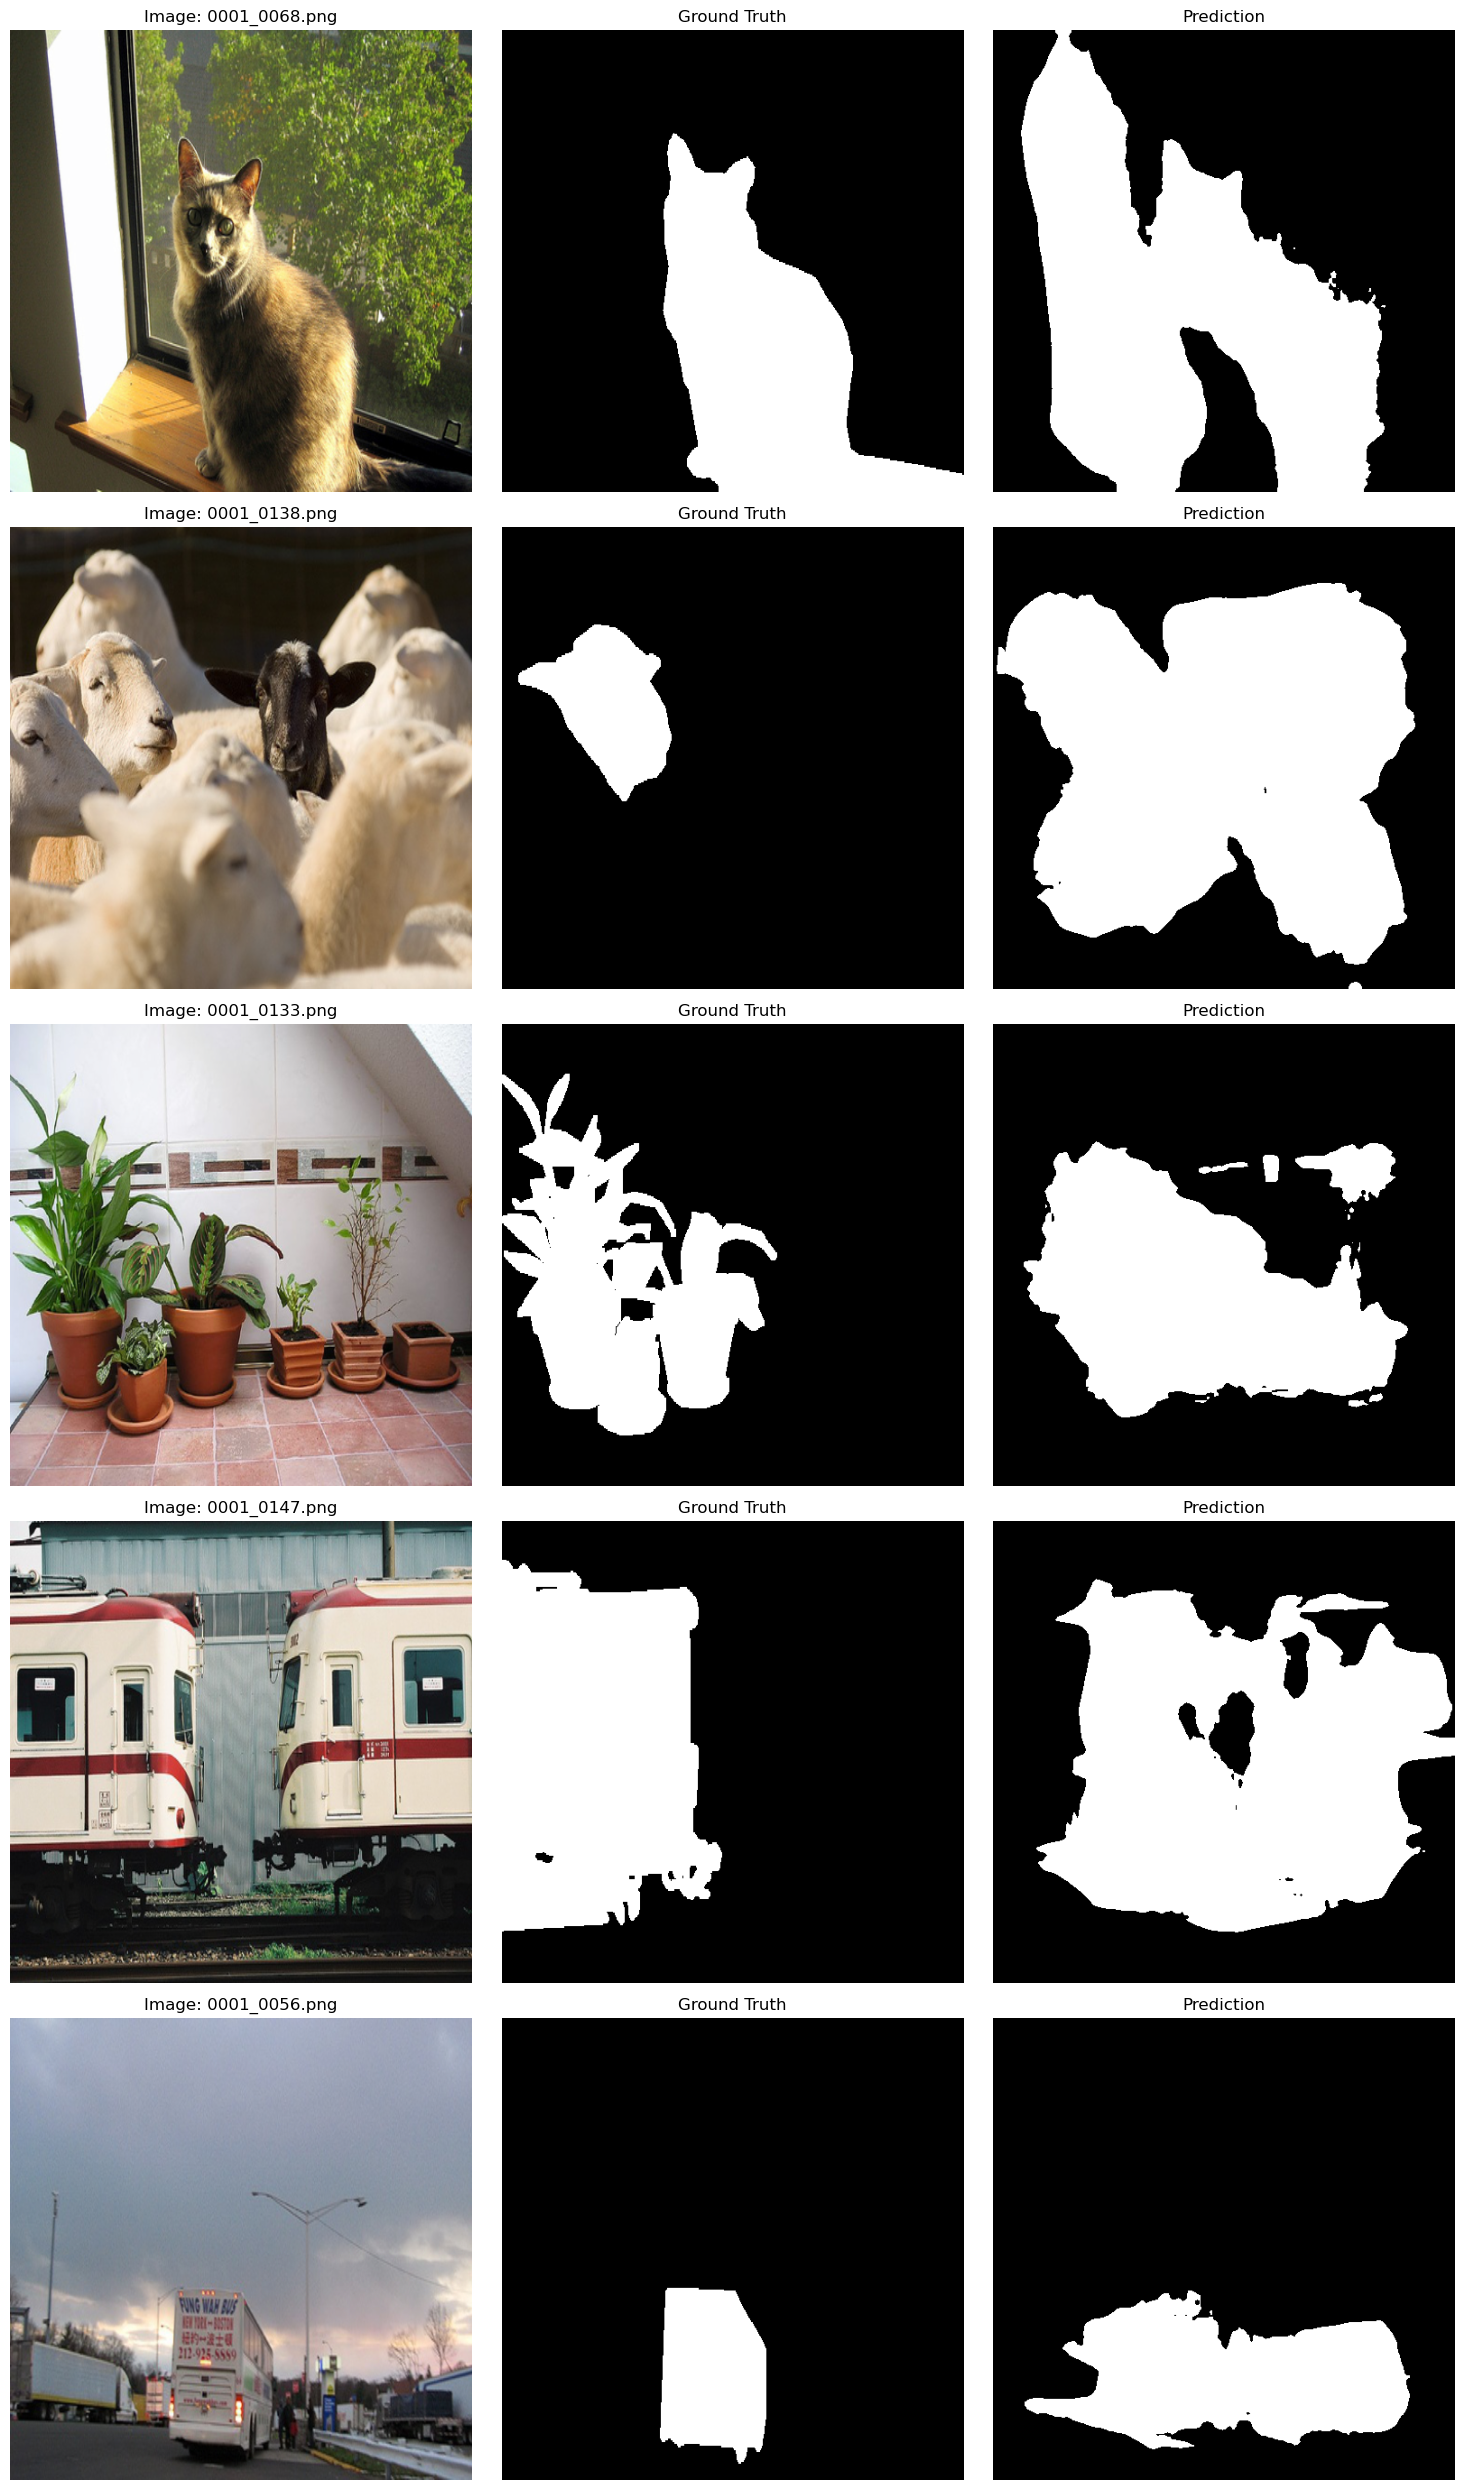

In [15]:
# Visualize predictions
model.load_state_dict(torch.load('best_segformer.pth', weights_only=True))
model.eval()

num_samples = min(5, len(test_dataset))
fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
if num_samples == 1:
    axes = axes.reshape(1, -1)

mean = np.array(IMAGENET_MEAN)
std  = np.array(IMAGENET_STD)

indices = np.random.choice(len(test_dataset), num_samples, replace=False)

with torch.no_grad():
    for i, data_idx in enumerate(indices):
        img, mask, fname = test_dataset[data_idx]
        logits = model(img.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits.squeeze()) > 0.5).long().cpu().numpy()
        
        # Denormalize
        img_vis = img.numpy().transpose(1, 2, 0) * std + mean
        img_vis = np.clip(img_vis, 0, 1)
        
        axes[i, 0].imshow(img_vis); axes[i, 0].set_title(f'Image: {fname}'); axes[i, 0].axis('off')
        axes[i, 1].imshow(mask.numpy(), cmap='gray'); axes[i, 1].set_title('Ground Truth'); axes[i, 1].axis('off')
        axes[i, 2].imshow(pred, cmap='gray'); axes[i, 2].set_title('Prediction'); axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

## Exercises

- Compare SegFormer with the U-Net results from the previous lecture. Which performs better and what are the trade-offs?
- Try a larger model (MiT-B2: depths=[3,4,6,3], embed_dims=[64,128,320,512]). How do results improve?
- Modify the dataset and decoder to handle multi-class segmentation instead of binary.
- Visualize the attention maps from different stages to see how multi-scale features differ.